# The Efficient Frontier and Two-Fund Theorem

The reason Harry Markowitz won the Nobel Prize is not because he came up with the idea of "diversification." People have known not to put all their eggs in one basket for thousands of years. He won the Nobel Prize because he was the first person in history to rigorously prove exactly how many eggs to put in exactly which baskets, using the strict laws of linear algebra and constrained optimization.

In [1]:
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy.optimize import minimize

In [2]:
# Setup the market data
mu = np.array([0.3, 0.5, 0.2])
sigma = np.array([
    [0.10, 0.02, 0.04],
    [0.02, 0.08, 0.01],
    [0.04, 0.01, 0.12]
])
mu_p = 0.8

The minimum-variance problem subject to a target expected return $\mu_p$ and budget constraint:
$$\min_w \frac{1}{2}w^T\Sigma w \quad \text{s.t.} \quad w^T\mu = \mu_p, \ \ \mathbf{1}^Tw = 1$$
The Lagrangian with two multipliers:
$$\mathcal{L} = \frac{1}{2}w^T\Sigma w - \lambda(w^T\mu - \mu_p) - \gamma(\mathbf{1}^Tw - 1)$$
First order condition: $\Sigma w - \lambda\mu - \gamma\mathbf{1} = 0 \implies w = \Sigma^{-1}(\lambda\mu + \gamma\mathbf{1})$

Solve for the multipliers by imposing the two constraints, using the three frontier scalars — $A = \mathbf{1}^T\Sigma^{-1}\mathbf{1}$, $B = \mathbf{1}^T\Sigma^{-1}\mu$, $C = \mu^T\Sigma^{-1}\mu$, and $D=AC-B^2$:

Return constraint $w^T\mu = \mu_p$​:
$$\mu^T\Sigma^{-1}(\lambda\mu + \gamma\mathbf{1}) =\mu_p, \qquad \lambda \mu^T\Sigma^{-1}\mu + \gamma\,\mu^T\Sigma^{-1}\mathbf{1} = \mu_p, \qquad \lambda C + \gamma B = \mu_p​$$
Budget constraint $\mathbf{1}^Tw = 1$:
$$\mathbf{1}^T\Sigma^{-1}(\lambda\mu + \gamma\mathbf{1}) = 1, \qquad \lambda\mathbf{1}^T\Sigma^{-1}\mu + \gamma\mathbf{1}^T\Sigma^{-1}\mathbf{1} =1,\qquad \lambda B + \gamma A = 1$$

Two linear equations in the two unknowns $\lambda$, $\gamma$. Stach them:
$$\begin{pmatrix} C & B \\ B & A \end{pmatrix}\begin{pmatrix} \lambda \\ \gamma \end{pmatrix} = \begin{pmatrix} \mu_p \\ 1 \end{pmatrix}$$
Solving it. Invert the $2\times2$:
$$\begin{pmatrix}\lambda\\\gamma\end{pmatrix} = \frac{1}{AC - B^2}\begin{pmatrix} A & -B \\ -B & C\end{pmatrix}\begin{pmatrix}\mu_p\\1\end{pmatrix} = \frac{1}{D}\begin{pmatrix} A\mu_p - B \\ C - B\mu_p\end{pmatrix}$$
The closed-form weights:
$$\boxed {\omega=\frac{C \Sigma^{-1} \mathbf{1} - B \Sigma^{-1} \mu}{D} + \mu_p \frac{A \Sigma^{-1} \mu - B \Sigma^{-1} \mathbf{1}}{D}}$$

Markowitz optimal weights $w \propto \Sigma^{-1}\mu$ blow up — **small noise in $\mu$ produces wild swings in $w$**. **The Jacobian view: $\Sigma$ collapses one direction to nearly zero, so $\Sigma^{-1}$ stretches that direction to nearly infinity.**

In [3]:
def min_variance_target_return(mu, sigma, mu_p):
    """
    Closed-form minimum-variance portfolio for a target expected return,
    subject to budget and return constraints (no inequality constraints):

        min  (1/2) w^T Sigma w
        s.t. w^T mu = mu_p,  1^T w = 1

    Solution:
        w* = (1/D) [ (A*mu_p - B) Sigma^-1 mu  +  (C - B*mu_p) Sigma^-1 1 ]
    where A = 1^T Sinv 1, B = 1^T Sinv mu, C = mu^T Sinv mu, D = A*C - B^2.

    Allows short positions (long-short). Returns weights summing to 1.

    Parameters
    ----------
    mu    : (n,) expected returns
    sigma : (n, n) covariance matrix, assumed SPD
    mu_p  : scalar target expected return

    Returns
    -------
    w : (n,) optimal weights
    """
    mu = np.asarray(mu, dtype=float).ravel()
    sigma = np.asarray(sigma, dtype=float)
    n = mu.shape[0]
    ones = np.ones(n)

    # Never form Σ^{-1} if you only need it applied to a vector. They're mathematically identical, but solve is faster and numerically more stable.
    # It uses an LU factorization under the hood instead of forming the full inverse, which squares the conditioning damage.
    x = np.linalg.solve(sigma, mu)      # Sigma^-1 mu
    y = np.linalg.solve(sigma, ones)    # Sigma^-1 1

    # Frontier scalars
    A = ones @ y                        # 1^T Sigma^-1 1
    B = ones @ x                        # 1^T Sigma^-1 mu   ( = mu^T Sigma^-1 1 )
    C = mu @ x                          # mu^T Sigma^-1 mu
    D = A * C - B * B                   # determinant of the 2x2 multiplier system

    if D <= 0 or not np.isfinite(D):
        raise ValueError(
            f"degenerate frontier (D={D:.3e}): mu and 1 are nearly collinear "
            "or Sigma is ill-conditioned"
        )

    lam = (A * mu_p - B) / D            # multiplier on the return constraint
    gam = (C - B * mu_p) / D            # multiplier on the budget constraint

    w = lam * x + gam * y              # w = Sigma^-1 (lam*mu + gam*1)
    return w
min_variance_target_return(mu, sigma, mu_p)

array([-0.16666667,  2.05555556, -0.88888889])

The moment you add no-shorting ($w \geq 0$) or a leverage cap, you reintroduce inequality constraints, complementary slackness kicks in, and you lose the closed form.

In [4]:
def min_variance_scipy(sigma, bounds=None):
    num_assets = len(sigma)
    # Define the Objective Function 
    # The Python `@` operator handles the matrix multiplication: w^T * Sigma * w
    def objective_function(w, cov_matrix):
        return w.T @ cov_matrix @ w

    # Define the Jacobian (The First-Order Derivative)
    # Passing the exact gradient prevents the solver from wasting time guessing it.
    # If you do not provide the jac argument, scipy will use "finite differences" to guess the gradient by perturbing the weights slightly thousands of times.
    # Because you mathematically know that the derivative is $2 \Omega w$, passing that function explicitly cuts the solver's computational time in half. This is pure execution alpha.
    def jacobian_derivative(w, cov_matrix):
        return 2 * cov_matrix @ w

    # Define the Constraints
    # Budget Constraint: sum(w) - 1.0 = 0
    def budget_constraint(w):
        return np.sum(w) - 1.0

    # SciPy expects constraints as a tuple of dictionaries
    constraints = ({'type': 'eq', 'fun': budget_constraint})

    # Define the Bounds
    # Long-Only Constraint: Each weight must be between 0.0 and 1.0
    bounds = tuple((0.0, 1.0) for _ in range(num_assets))

    # Set the Initial Guess
    # The solver needs a starting point. Equal weighting is the standard default.
    initial_guess = np.ones(num_assets) / num_assets

    # Run the Optimizer
    # The SLSQP Engine is one of the only algorithms in SciPy that can handle both Bounds (e.g., w >= 0) and Constraints (e.g., sum(w) = 1) simultaneously for quadratic functions.
    # trust-constr` is the only real alternative that does, but SLSQP is faster and more standard for smooth QP-shaped problems this size.
    result = minimize(
        fun=objective_function,
        x0=initial_guess,
        args=(sigma,),       # Passes the covariance matrix to our functions
        method='SLSQP',           # The algorithm used for constrained optimization
        jac=jacobian_derivative,  # Our custom gradient function
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 500}
    )

    # Output the Result
    # Always check res.success and inspect res.x for sanity (weights summing to 1, no wild values). SLSQP can silently return a non-converged point.
    if result.success:
        print(f"Optimal Weights: {result.x.round(4)}")
        print(f"Minimum Variance Achieved: {result.fun:.4f}")
    else:
        print("Optimization Failed:", result.message)
min_variance_scipy(sigma)

Optimal Weights: [0.2632 0.4795 0.2573]
Minimum Variance Achieved: 0.0462


SLSQP is a general nonlinear solver, not a QP solver. It doesn't know your problem is convex, so it can be slower and less robust than a true QP method on large/ill-conditioned problems.

For a learning toolkit at small-to-medium n it's perfectly fine, and using it teaches you the constraint-specification mechanics. But have a solver='cvxpy' path in mind for when you scale up or hit a near-singular Σ; CVXPY+OSQP will recognize the QP structure and be far more stable.

In [5]:
def min_variance_cvxpy(sigma, bounds=None, long_only=True):
    """
    Global minimum-variance portfolio via CVXPY.
        min  w^T Sigma w
        s.t. 1^T w = 1, plus optional bounds
    """
    n = sigma.shape[0]
    w = cp.Variable(n)

    # CVXPY knows it's a convex QP, so it uses OSQP's interior-point method rather than treating it as a generic nonlinear problem the way SLSQP does.
    # CVXPY checks convexity by checking Σ⪰0, and a slightly-negative eigenvalue makes it refuse to solve, throwing "Problem does not follow DCP rules." 
    # PSD-wrap Sigma so CVXPY recognizes the QP as convex even if the input has tiny negative eigenvalues from estimation noise.`psd_wrap` tells CVXPY "trust me, treat this as PSD.
    objective = cp.Minimize(cp.quad_form(w, cp.psd_wrap(sigma)))

    constraints = [cp.sum(w) == 1]
    if long_only:
        constraints.append(w >= 0)
    if bounds is not None:
        lo, hi = bounds
        constraints += [w >= lo, w <= hi]

    prob = cp.Problem(objective, constraints)
    # For pure QPs it's excellent. If you later add second-order-cone constraints (e.g., an explicit risk cap rather than risk in the objective), switch to `cp.CLARABEL`, also free.
    prob.solve(solver=cp.OSQP)            # free QP solver, no license

    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise ValueError(f"solve failed: {prob.status}")
    return w.value
min_variance_cvxpy(sigma)

array([0.26315789, 0.47953216, 0.25730994])

Solve the minimum-variance problem for every level of target return $\mu_p$.

As you sweep $\mu_p$, the optimal $w$ traces a curve. Plotted in (risk, return) space — $\sigma_p$ on the x-axis, $\mu_p$ on the y-axis — this curve is a **hyperbola**, the **minimum-variance frontier**. The upper half (above the minimum-variance point) is the **efficient frontier**: portfolios where you can't get more return without more risk.

The minimum variance achievable at target return $\mu_p$ is:

$$ \sigma_p^2 = \frac{A\mu_p^2 - 2B\mu_p + C}{AC - B^2} $$

That's the equation of the **hyperbola**. Notice it's quadratic in $\mu_p$ — the parabola in variance, hyperbola in standard deviation. **Everything is computed from $\Sigma^{-1}$, $\mu$, and $\mathbf{1}$ — which is why a clean, invertible $\Sigma$ matters so much.**

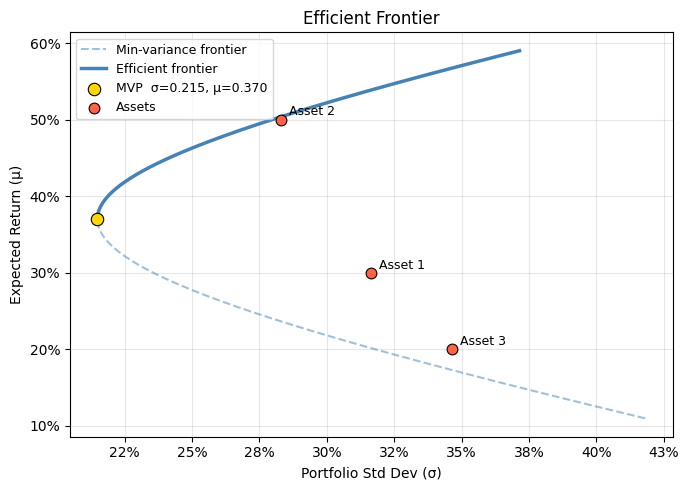

In [6]:
def plot_efficient_frontier(mu, sigma, n_points=500, ax=None):
    mu = np.asarray(mu, dtype=float).ravel()
    sigma = np.asarray(sigma, dtype=float)
    ones = np.ones(len(mu))

    x = np.linalg.solve(sigma, mu)
    y = np.linalg.solve(sigma, ones)
    A = ones @ y
    B = ones @ x
    C = mu @ x
    D = A * C - B ** 2

    mu_mvp  = B / A
    std_mvp = 1.0 / np.sqrt(A)

    mu_grid = np.linspace(mu.min() - 0.3 * (mu.max() - mu.min()),
                          mu.max() + 0.3 * (mu.max() - mu.min()), n_points)
    stds = np.sqrt((A * mu_grid**2 - 2 * B * mu_grid + C) / D)

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    ax.plot(stds, mu_grid, color="steelblue", lw=1.5, ls="--", alpha=0.5,
            label="Min-variance frontier")
    eff = mu_grid >= mu_mvp
    ax.plot(stds[eff], mu_grid[eff], color="steelblue", lw=2.5,
            label="Efficient frontier")
    ax.scatter(std_mvp, mu_mvp, s=80, zorder=5, color="gold", edgecolors="k",
               lw=0.8, label=f"MVP  σ={std_mvp:.3f}, μ={mu_mvp:.3f}")
    asset_stds = np.sqrt(np.diag(sigma))
    ax.scatter(asset_stds, mu, s=60, zorder=5, color="tomato", edgecolors="k",
               lw=0.8, label="Assets")
    for i, (s, r) in enumerate(zip(asset_stds, mu)):
        ax.annotate(f"Asset {i+1}", (s, r), textcoords="offset points",
                    xytext=(6, 3), fontsize=9)

    ax.set_xlabel("Portfolio Std Dev (σ)")
    ax.set_ylabel("Expected Return (μ)")
    ax.set_title("Efficient Frontier")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return ax

plot_efficient_frontier(mu, sigma)
plt.show()

**Two-fund theorem**: $w=g+\mu_p h$ is affine in the target return $\mu_p$. Two fixed vectors $g$ and $h$ generate the entire frontier as you vary $\mu_p$.
Grouping by two frontier portfolios $g$ and $g+h$, $w=(1-\mu_p)g+\mu_p(g+h)$, and every other froniter portfolio is a combination of them. Pick two frontier portfolios $w_1, w_2$; then every frontier portfolio is:

$$
w = \lambda w_1 + (1-\lambda)w_2 \quad \text{for some } \lambda \in \mathbb{R}
$$

**Why it matters:** the entire frontier — infinitely many portfolios — is spanned by just two. This is the math behind "you only need a stock fund and a bond fund." It falls directly out of the linearity of the Lagrangian first-order conditions: the optimal $w$ is an affine function of $\mu_p$, so any two solutions determine the whole line.

The Lagrangian gives $\Sigma w = \lambda\mu + \gamma\mathbf{1}$, so $w = \Sigma^{-1}(\lambda\mu + \gamma\mathbf{1})$ — and the two multipliers $\lambda, \gamma$ turn out to be affine in $\mu_p$ once you impose the constraints. So $w$ is a linear-in-$\mu_p$ combination of two fixed vectors $\Sigma^{-1}\mu$ and $\Sigma^{-1}\mathbf{1}$. Any two values of $\mu_p$ give two $w$’s whose span recovers all the others — two points pinning down the line.